##  Notebook 08 - Feature Space ANalysis

### Objective
Previous notebooks investigated each acoustic feature independently.

- RMS Energy
- Spectral Centroid
- MFCCs

Each feature revealed different aspects of machine behaviour, but anomaly detection models do not operate on individual features—they learn from the **combined feature space**.

The objectives of this notebook are:

1. Merge all extracted features into a single feature matrix.
2. Verify data quality before model training.
3. Study statistical properties of the engineered features.
4. Identify correlations and redundancy among features.
5. Prepare for dimensionality reduction and feature selection.

This notebook serves as the bridge between signal processing and machine learning.


### Imports

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from src.config import *
plt.style.use("default")
sns.set_theme(style="whitegrid")
random_state = 42

## Load Feature Tables

The features extracted in previous notebooks are stored independently.

This section loads:

- RMS summary
- Spectral Centroid summary
- MFCC summary

These will be merged into a single feature table.

In [2]:
rms = pd.read_csv(results_path/"rms_summary.csv")
centroid = pd.read_csv(results_path/"spectral_centroid_summary.csv")
mfcc = pd.read_csv(results_path/"mfcc_summary.csv")

In [3]:
print("RMS shape:", rms.shape)
print("Centroid shape:", centroid.shape)
print("MFCC shape:", mfcc.shape)

RMS shape: (1149, 3)
Centroid shape: (1149, 10)
MFCC shape: (1149, 42)


In [4]:
display(rms.head())

,file_name,label,rms
0,00000000.wav,Normal,0.006863
1,00000001.wav,Normal,0.006892
2,00000002.wav,Normal,0.007001
3,00000003.wav,Normal,0.006864
4,00000004.wav,Normal,0.006833


In [5]:
display(centroid.head())

,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,centroid_iqr,file_name,label
0,2377.057822,203.249647,1962.135768,3639.686883,1677.551115,2243.546767,2495.872024,252.325257,00000000.wav,Normal
1,2615.976632,163.012387,2204.683950,3477.425155,1272.741205,2504.840504,2701.621417,196.780913,00000001.wav,Normal
2,2420.451821,221.444349,1879.446225,3125.582353,1246.136128,2277.626044,2554.681328,277.055284,00000002.wav,Normal
3,2640.560590,143.981090,2293.331119,3325.892444,1032.561324,2548.801170,2723.995983,175.194813,00000003.wav,Normal
4,2363.787353,161.885214,2017.350298,3058.560910,1041.210611,2262.940960,2441.204920,178.263960,00000004.wav,Normal


In [6]:
display(mfcc.head())

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_17_mean,mfcc_17_std,mfcc_18_mean,mfcc_18_std,mfcc_19_mean,mfcc_19_std,mfcc_20_mean,mfcc_20_std,file_name,label
0,-285.32410,13.046962,61.081543,8.571634,-7.742035,7.418871,16.976044,6.905290,8.054357,6.616282,...,-0.096999,3.979113,-3.670382,3.697155,-4.089489,3.840694,-2.095833,3.601322,00000000.wav,Normal
1,-282.27840,10.958236,51.239525,7.887704,-11.985823,7.473280,5.065098,6.930391,1.280624,7.068424,...,-1.623434,4.129343,-2.175425,3.928446,-7.778472,4.005436,-7.840248,3.642836,00000001.wav,Normal
2,-284.63037,13.951112,60.277317,10.349363,-5.456760,8.053712,16.463049,7.541470,5.267432,6.943223,...,-1.709660,4.066159,-0.542535,4.208001,-1.267911,3.588922,-0.160735,3.821595,00000002.wav,Normal
3,-284.53845,11.082034,51.455030,7.180773,-4.688273,7.678318,9.098770,6.373854,1.492822,5.265297,...,1.572953,4.329129,-0.524022,3.945969,-6.199827,4.392107,-6.244669,3.975851,00000003.wav,Normal
4,-281.46950,10.882649,63.417408,7.536225,-6.258961,7.911538,18.218475,7.109123,2.336891,5.741307,...,-1.234870,3.771016,-2.442800,3.671000,-3.763920,3.474387,-1.010000,3.534326,00000004.wav,Normal


## Merge Features

Each CSV contains one row per recording.

The common keys are  **file_name and label**.

After merging, every recording should contain all extracted features.

In [3]:
features = rms.merge(centroid, on = ["file_name", "label"], how = "inner")
features = features.merge(mfcc, on = ["file_name", "label"], how = "inner")


In [4]:
print("Merged feature matrix")
print(features.shape)
features.head()

Merged feature matrix
(1149, 51)


,file_name,label,rms,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,...,mfcc_16_mean,mfcc_16_std,mfcc_17_mean,mfcc_17_std,mfcc_18_mean,mfcc_18_std,mfcc_19_mean,mfcc_19_std,mfcc_20_mean,mfcc_20_std
0,00000000.wav,Normal,0.006863,2377.057822,203.249647,1962.135768,3639.686883,1677.551115,2243.546767,2495.872024,...,3.109998,3.625720,-0.096999,3.979113,-3.670382,3.697155,-4.089489,3.840694,-2.095833,3.601322
1,00000001.wav,Normal,0.006892,2615.976632,163.012387,2204.683950,3477.425155,1272.741205,2504.840504,2701.621417,...,-2.359842,4.183728,-1.623434,4.129343,-2.175425,3.928446,-7.778472,4.005436,-7.840248,3.642836
2,00000002.wav,Normal,0.007001,2420.451821,221.444349,1879.446225,3125.582353,1246.136128,2277.626044,2554.681328,...,-0.199371,4.173311,-1.709660,4.066159,-0.542535,4.208001,-1.267911,3.588922,-0.160735,3.821595
3,00000003.wav,Normal,0.006864,2640.560590,143.981090,2293.331119,3325.892444,1032.561324,2548.801170,2723.995983,...,2.028418,4.115705,1.572953,4.329129,-0.524022,3.945969,-6.199827,4.392107,-6.244669,3.975851
4,00000004.wav,Normal,0.006833,2363.787353,161.885214,2017.350298,3058.560910,1041.210611,2262.940960,2441.204920,...,0.518599,3.951528,-1.234870,3.771016,-2.442800,3.671000,-3.763920,3.474387,-1.010000,3.534326


In [4]:
group_a = pd.read_csv(results_path/"group_a.csv")
group_b = pd.read_csv(results_path/"group_b.csv")
group_c = pd.read_csv(results_path/"group_c.csv")

In [5]:
# Assigning the labels
features["Group"] = "Unknown"
features.loc[features.file_name.isin(group_a.file_name) &
    features.label.isin(group_a.label), "Group"] = "Normal"
features.loc[features.file_name.isin(group_b.file_name) &
    features.label.isin(group_b.label), "Group"] = "Overlap"
features.loc[features.file_name.isin(group_c.file_name) &
    features.label.isin(group_c.label), "Group"] = "Obvious"

In [6]:
features["Group"].value_counts()

Group
Unknown    1134
Normal        5
Obvious       5
Overlap       5
Name: count, dtype: int64

## Data Quality Assessment

Before applying dimensionality reduction or machine learning algorithms, it is important to verify that the extracted feature matrix is complete and internally consistent.

In [8]:
# Missing Values
missing = features.isnull().sum()
missing = missing[missing > 0]
missing

Series([], dtype: int64)

In [9]:
# Check data types
features.dtypes

file_name          object
label              object
rms               float64
centroid_mean     float64
centroid_std      float64
centroid_min      float64
centroid_max      float64
centroid_delta    float64
centroid_q25      float64
centroid_q75      float64
centroid_iqr      float64
mfcc_1_mean       float64
mfcc_1_std        float64
mfcc_2_mean       float64
mfcc_2_std        float64
mfcc_3_mean       float64
mfcc_3_std        float64
mfcc_4_mean       float64
mfcc_4_std        float64
mfcc_5_mean       float64
mfcc_5_std        float64
mfcc_6_mean       float64
mfcc_6_std        float64
mfcc_7_mean       float64
mfcc_7_std        float64
mfcc_8_mean       float64
mfcc_8_std        float64
mfcc_9_mean       float64
mfcc_9_std        float64
mfcc_10_mean      float64
mfcc_10_std       float64
mfcc_11_mean      float64
mfcc_11_std       float64
mfcc_12_mean      float64
mfcc_12_std       float64
mfcc_13_mean      float64
mfcc_13_std       float64
mfcc_14_mean      float64
mfcc_14_std 

In [8]:
features.to_csv(results_path/"features.csv", index = False)

In [18]:
# Summary
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149 entries, 0 to 1148
Data columns (total 52 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   file_name       1149 non-null   object 
 1   label           1149 non-null   object 
 2   rms             1149 non-null   float64
 3   centroid_mean   1149 non-null   float64
 4   centroid_std    1149 non-null   float64
 5   centroid_min    1149 non-null   float64
 6   centroid_max    1149 non-null   float64
 7   centroid_delta  1149 non-null   float64
 8   centroid_q25    1149 non-null   float64
 9   centroid_q75    1149 non-null   float64
 10  centroid_iqr    1149 non-null   float64
 11  mfcc_1_mean     1149 non-null   float64
 12  mfcc_1_std      1149 non-null   float64
 13  mfcc_2_mean     1149 non-null   float64
 14  mfcc_2_std      1149 non-null   float64
 15  mfcc_3_mean     1149 non-null   float64
 16  mfcc_3_std      1149 non-null   float64
 17  mfcc_4_mean     1149 non-null   f

## Feature Statistics

<b> Descriptive Statistics - </b>
Understanding the range, variability and distribution of engineered features helps identifying normal scales, outliers and potential preprocessing requirements before model training.

In [10]:
statistics = features.describe().T
statistics

,count,mean,std,min,25%,50%,75%,max
rms,1149.0,0.006679,0.001828,0.004839,0.005917,0.006022,0.006736,0.015876
centroid_mean,1149.0,2309.567452,261.865990,1474.449353,2111.423973,2322.055701,2475.248149,3538.405234
centroid_std,1149.0,186.189016,51.087626,52.780464,153.696963,181.066127,210.094687,626.390526
centroid_min,1149.0,1870.796040,277.506129,1049.699691,1668.538452,1857.180645,2060.961273,3209.865380
centroid_max,1149.0,3108.079483,347.575238,1652.720309,2902.227081,3094.410016,3325.350057,4369.755726
centroid_delta,1149.0,1237.283444,333.845708,276.271437,1004.574464,1205.662214,1428.403158,2663.609953
centroid_q25,1149.0,2186.032517,273.098949,1374.580014,1960.870469,2196.711681,2361.682722,3449.457862
centroid_q75,1149.0,2411.867981,264.757375,1541.653892,2219.651797,2419.698178,2579.366677,3623.522730
centroid_iqr,1149.0,225.835464,82.668274,64.164553,180.495162,212.933913,250.613445,1149.598727
mfcc_1_mean,1149.0,-299.102404,23.073241,-352.565400,-313.439730,-304.284970,-286.856140,-219.258940


In [21]:
statistics.to_csv(results_path/"features_statistics.csv")

In [11]:
# Largest variance
statistics.sort_values(by = 'std', ascending = False).head(10)

,count,mean,std,min,25%,50%,75%,max
centroid_max,1149.0,3108.079483,347.575238,1652.720309,2902.227081,3094.410016,3325.350057,4369.755726
centroid_delta,1149.0,1237.283444,333.845708,276.271437,1004.574464,1205.662214,1428.403158,2663.609953
centroid_min,1149.0,1870.796040,277.506129,1049.699691,1668.538452,1857.180645,2060.961273,3209.865380
centroid_q25,1149.0,2186.032517,273.098949,1374.580014,1960.870469,2196.711681,2361.682722,3449.457862
centroid_q75,1149.0,2411.867981,264.757375,1541.653892,2219.651797,2419.698178,2579.366677,3623.522730
centroid_mean,1149.0,2309.567452,261.865990,1474.449353,2111.423973,2322.055701,2475.248149,3538.405234
centroid_iqr,1149.0,225.835464,82.668274,64.164553,180.495162,212.933913,250.613445,1149.598727
centroid_std,1149.0,186.189016,51.087626,52.780464,153.696963,181.066127,210.094687,626.390526
mfcc_1_mean,1149.0,-299.102404,23.073241,-352.565400,-313.439730,-304.284970,-286.856140,-219.258940
mfcc_2_mean,1149.0,67.348651,12.624746,18.219568,59.538830,67.973170,76.686325,110.050970


In [12]:
# Smallest variance
statistics.sort_values(by = "std").head(10)

,count,mean,std,min,25%,50%,75%,max
rms,1149.0,0.006679,0.001828,0.004839,0.005917,0.006022,0.006736,0.015876
mfcc_20_std,1149.0,3.569013,0.366837,2.444556,3.352953,3.538413,3.748261,6.149615
mfcc_19_std,1149.0,3.617363,0.374298,2.492346,3.394696,3.596487,3.820774,7.114625
mfcc_16_std,1149.0,3.834691,0.400461,2.528901,3.581906,3.818429,4.071132,6.855846
mfcc_18_std,1149.0,3.692409,0.408712,2.547962,3.436084,3.663418,3.913352,6.430886
mfcc_17_std,1149.0,3.775214,0.411060,2.590401,3.536202,3.760640,4.011818,7.031220
mfcc_15_std,1149.0,3.911624,0.412100,2.342897,3.648915,3.877260,4.158247,6.217106
mfcc_14_std,1149.0,4.078112,0.448246,2.521628,3.807841,4.063537,4.325685,6.001373
mfcc_13_std,1149.0,4.171067,0.487357,2.614767,3.879621,4.144825,4.447924,7.523928
mfcc_12_std,1149.0,4.289339,0.546718,2.544269,3.948653,4.252576,4.618078,8.823551


In [13]:
# Selecting Numerical Features
numeric_features = features.select_dtypes(include = np.number)
numeric_features.head()

,rms,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,centroid_iqr,mfcc_1_mean,...,mfcc_16_mean,mfcc_16_std,mfcc_17_mean,mfcc_17_std,mfcc_18_mean,mfcc_18_std,mfcc_19_mean,mfcc_19_std,mfcc_20_mean,mfcc_20_std
0,0.006863,2377.057822,203.249647,1962.135768,3639.686883,1677.551115,2243.546767,2495.872024,252.325257,-285.32410,...,3.109998,3.625720,-0.096999,3.979113,-3.670382,3.697155,-4.089489,3.840694,-2.095833,3.601322
1,0.006892,2615.976632,163.012387,2204.683950,3477.425155,1272.741205,2504.840504,2701.621417,196.780913,-282.27840,...,-2.359842,4.183728,-1.623434,4.129343,-2.175425,3.928446,-7.778472,4.005436,-7.840248,3.642836
2,0.007001,2420.451821,221.444349,1879.446225,3125.582353,1246.136128,2277.626044,2554.681328,277.055284,-284.63037,...,-0.199371,4.173311,-1.709660,4.066159,-0.542535,4.208001,-1.267911,3.588922,-0.160735,3.821595
3,0.006864,2640.560590,143.981090,2293.331119,3325.892444,1032.561324,2548.801170,2723.995983,175.194813,-284.53845,...,2.028418,4.115705,1.572953,4.329129,-0.524022,3.945969,-6.199827,4.392107,-6.244669,3.975851
4,0.006833,2363.787353,161.885214,2017.350298,3058.560910,1041.210611,2262.940960,2441.204920,178.263960,-281.46950,...,0.518599,3.951528,-1.234870,3.771016,-2.442800,3.671000,-3.763920,3.474387,-1.010000,3.534326


In [14]:
print("Number of numerical features:", numeric_features.shape[1])

Number of numerical features: 49


## Correlation Analysis

#### Feature Correlation
Highly correlated features often describe similar acoustic characteristics.

Studying the correlation matrix helps identify redundancy before feature selection.

In [26]:
corr = numeric_features.corr()

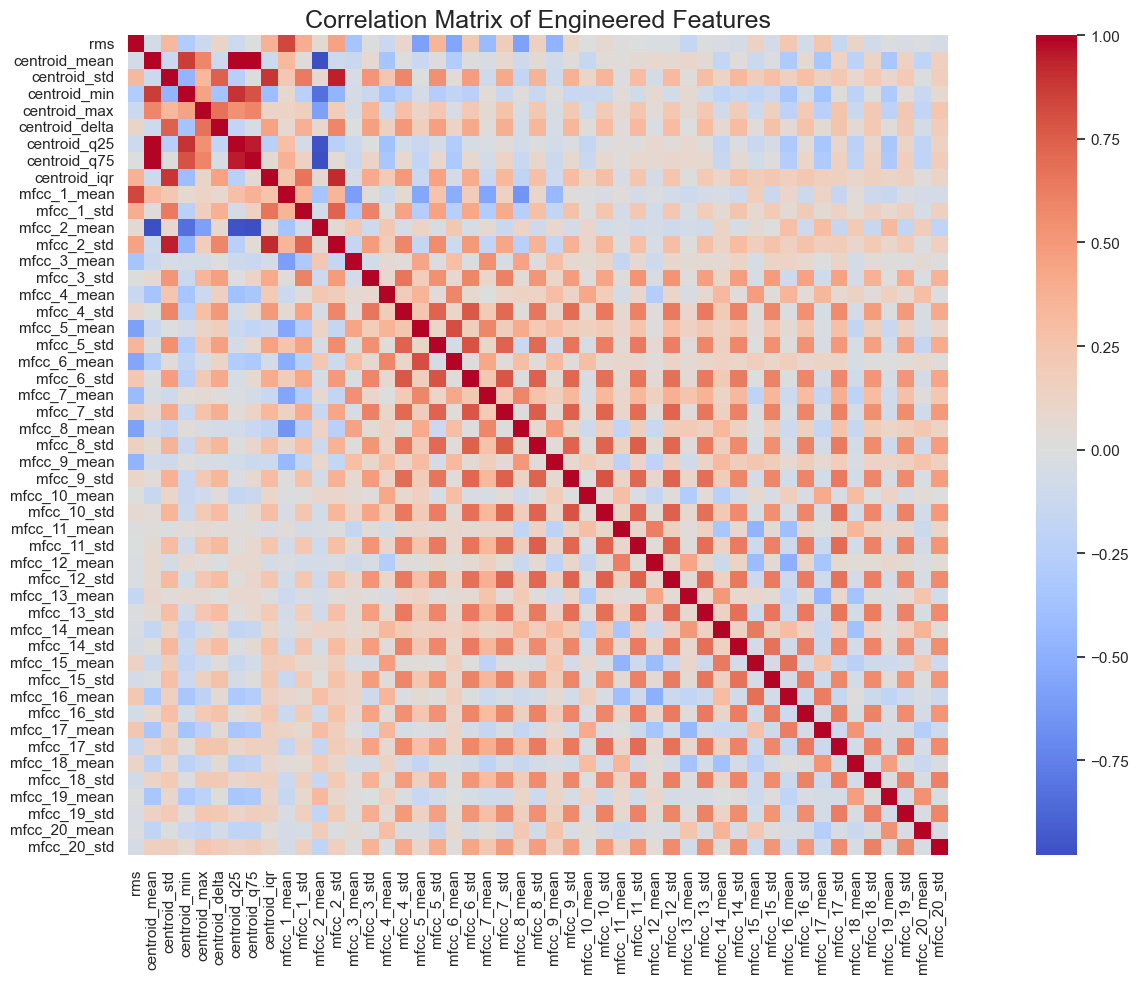

In [37]:
plt.figure(figsize = (18, 10))
sns.heatmap(corr, cmap = "coolwarm", center = 0, square = True)
plt.title("Correlation Matrix of Engineered Features", fontsize = 18)
plt.tight_layout()
plt.savefig(results_path/"figures"/"feature_space"/"feature_correlation_matrix.png",
            dpi = 150, bbox_inches = "tight")
plt.show()

### Strongest Correlations

In [39]:
corr_matrix = corr.abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k =1).astype(bool))

In [42]:
strong_pairs = (upper.stack().sort_values(ascending = False))


In [41]:
strong_pairs = (strong_pairs.reset_index())
strong_pairs.columns = ["Feature 1", "Feature 2", "Correaltion"]
strong_pairs.head(20)

,Feature 1,Feature 2,Correaltion
0,centroid_mean,centroid_q25,0.988234
1,centroid_mean,centroid_q75,0.986186
2,centroid_mean,mfcc_2_mean,0.979670
3,centroid_q75,mfcc_2_mean,0.972282
4,centroid_q25,mfcc_2_mean,0.961496
5,centroid_q25,centroid_q75,0.953223
6,centroid_std,mfcc_2_std,0.941524
7,centroid_iqr,mfcc_2_std,0.916278
8,centroid_min,centroid_q25,0.893511
9,centroid_std,centroid_iqr,0.889461


In [43]:
strong_pairs.to_csv(results_path/"strong_features_correlation.csv", index = False)

### Observations

1. <b>Preliminary Feature Selection</b>

Based on redundancy analysis, the most promising candidate features are:
* Spectral Centroid Standard Deviation
* MFCC-1 Mean
* MFCC-1 Standard Deviation
* MFCC-2 Mean
* MFCC-2 Standard Deviation
* MFCC-3 Mean
These features will be validated further using PCA, t-SNE, and feature-space visualization before being finaized for model training.

2. An unexpected negative correlation was observed between <b> MFCC-2 Mean and MFCC-8 Mean.</b> Unlike the strong positive correlations observed among neighbouring MFCC coefficients, this inverse relationship suggests that these coefficients may respond differently to changes in the spectral envelope. PCA will be used in the next section to determine whether MFCC-8 contributes an independent direction of variation or simply represents the opposite loading of the same latent component.


# Part 2 - Feature Space Visualization

### Standardization
The engineered features have very different numerical ranges (e.g., RMS, Spectral Centroid, MFCCs). Before applying dimensionality reduction techniques such as PCA and t-SNE, the features are standardized to zero mean and unit variance. This ensures that features with larger numerical scales do not dominate the analysis.

In [15]:
from sklearn.preprocessing import StandardScaler
x = numeric_features.copy()
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [16]:
print(x_scaled.shape)

(1149, 49)


### PCA - Principal Component Analysis
PCA projects the high-dimensional feature space into a lower-dimensional representation while preserving as much variance as possible.

Research questions:
- Do normal and abnormal resordings naturally separate?
- Do overlapping anomalies occupy a distinct region?
- Which engineered features contribute most to the separation?

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2, random_state = 42)
x_pca = pca.fit_transform(x_scaled)

In [19]:
explained = pd.DataFrame({"Principal Component":["PC1", "PC2"],
                          "Explained Variance": pca.explained_variance_ratio_
                         })
explained

,Principal Component,Explained Variance
0,PC1,0.262257
1,PC2,0.133756


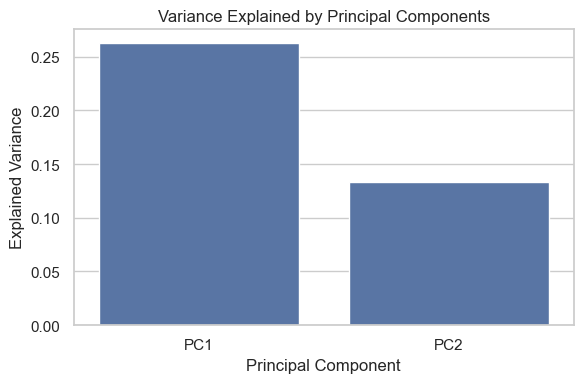

In [24]:
plt.figure(figsize = (6, 4))
sns.barplot(
    data = explained, x = "Principal Component", 
    y = "Explained Variance"
)
plt.title("Variance Explained by Principal Components")
plt.tight_layout()
plt.savefig(results_path/"figures"/"feature_space"/"pca_variance.png",
            dpi = 150)
plt.show()

In [25]:
pca_df = pd.DataFrame({
    "PC1": x_pca[:,0],
    "PC2": x_pca[:,1],
    "Group": features["Group"]
})

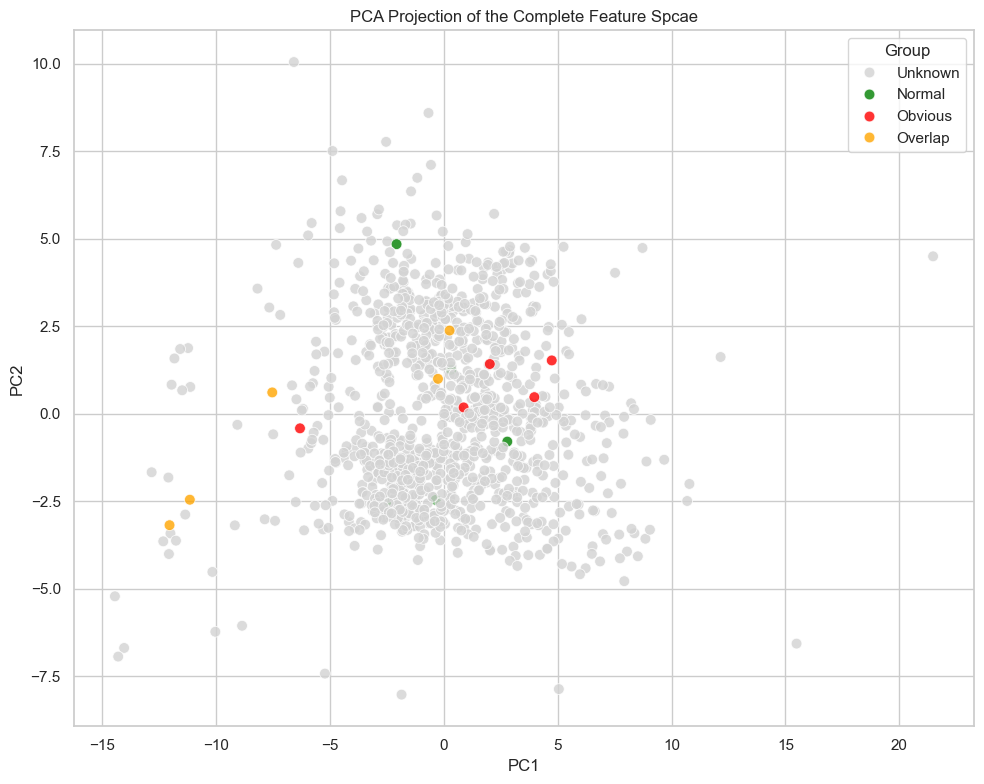

In [29]:
plt.figure(figsize = (10, 8))
palette = {
    "Unknown": "lightgray", "Normal": "green", 
    "Overlap": "orange", "Obvious": "red"}
sns.scatterplot(data = pca_df, x = "PC1", y = "PC2",
                hue = "Group", palette = palette, alpha = 0.8, s = 60)
plt.title("PCA Projection of the Complete Feature Spcae")
plt.tight_layout()
plt.savefig(results_path/"figures"/"feature_space"/"pca_projection.png",
            dpi = 150)
plt.show()


### PCA Loadings
The loading matrix indicates how strongly each egineered feature contributes to the princpal components. Features with large absolute loadings are the primary drivers of variance.

In [30]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns = ["PC1", "PC2"],
    index = numeric_features.columns
)

loadings.head()

,PC1,PC2
rms,0.018559,-0.028026
centroid_mean,0.019703,0.360997
centroid_std,0.156758,-0.119757
centroid_min,-0.048949,0.344130
centroid_max,0.098452,0.203404


In [31]:
loadings["Importance"] = (
    loadings["PC1"].abs() + loadings["PC2"].abs()
)
loadings = loadings.sort_values("Importance", ascending = False)
loadings.head(20)

,PC1,PC2,Importance
centroid_min,-0.048949,0.344130,0.393079
centroid_q75,0.038601,0.343963,0.382563
centroid_mean,0.019703,0.360997,0.380699
mfcc_2_mean,-0.033592,-0.345496,0.379088
centroid_q25,-0.001240,0.367427,0.368666
centroid_max,0.098452,0.203404,0.301856
centroid_std,0.156758,-0.119757,0.276515
mfcc_4_std,0.234150,-0.038769,0.272919
mfcc_4_mean,0.037928,-0.220924,0.258852
mfcc_17_std,0.213351,0.044771,0.258123


In [32]:
loadings.to_csv(results_path/"pca_loadings.csv")

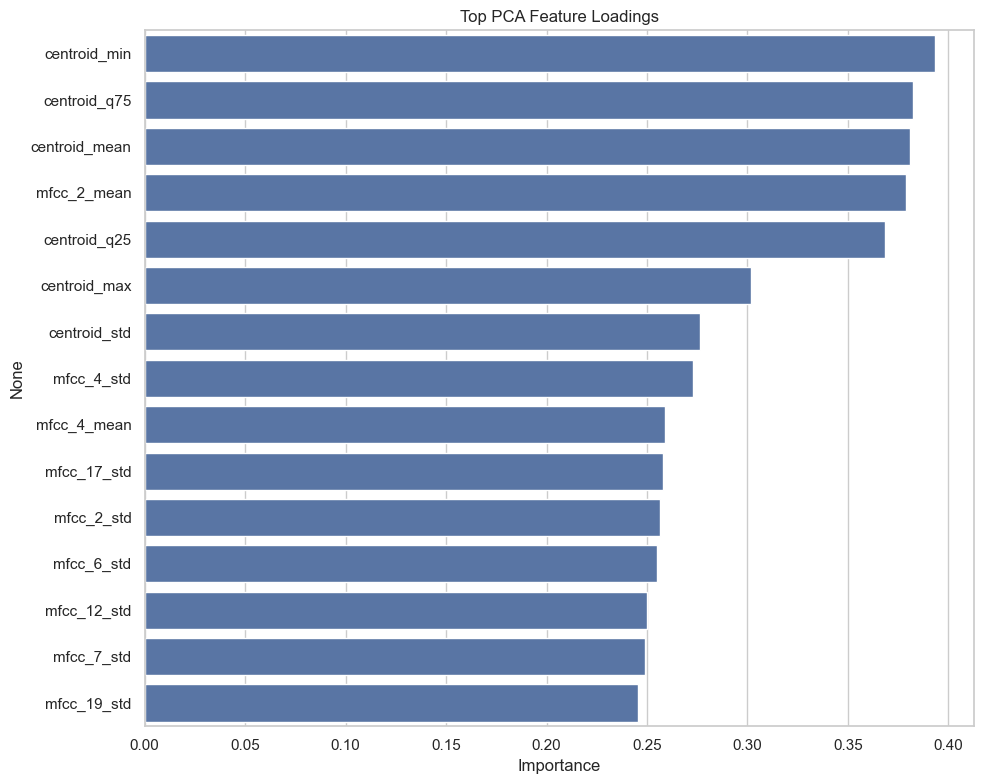

In [35]:
plt.figure(figsize = (10, 8))
sns.barplot(
    data = loadings.head(15), x = "Importance", 
    y = loadings.head(15).index)
plt.title("Top PCA Feature Loadings")
plt.tight_layout()
plt.savefig(results_path/"figures"/"feature_space"/"top_pca_laodings.png", dpi = 150)
plt.show()

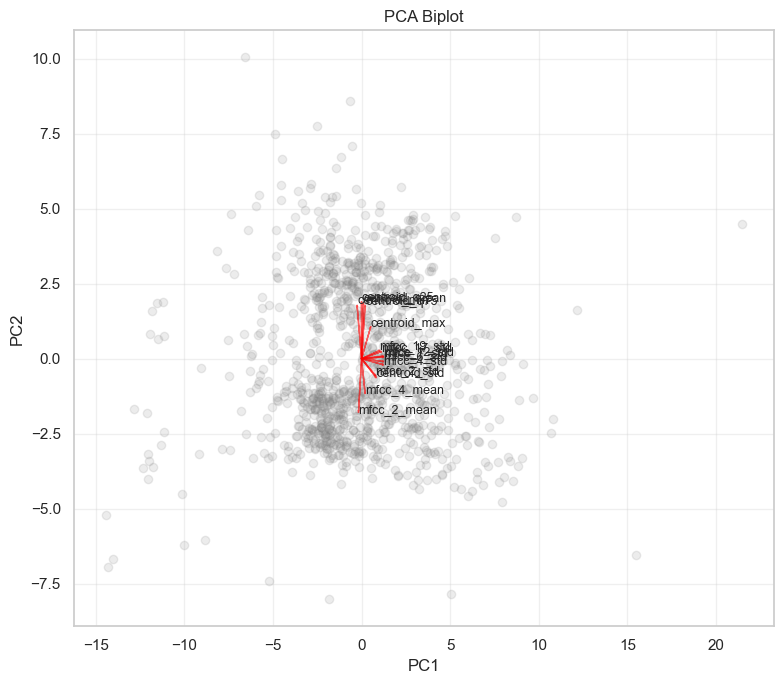

In [43]:
plt.figure(figsize=(8, 7))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    alpha=0.15,
    color="gray"
)

scale = 5

for feature in loadings.index[:15]:

    plt.arrow(
        0,
        0,
        loadings.loc[feature,"PC1"]*scale,
        loadings.loc[feature,"PC2"]*scale,
        color="red",
        alpha=0.6,
        head_width=0.05
    )

    plt.text(
        loadings.loc[feature,"PC1"]*scale*1.05,
        loadings.loc[feature,"PC2"]*scale*1.05,
        feature,
        fontsize=9
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Biplot")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    results_path/"figures"/"feature_space"/"pca_biplot.png",
    dpi=300
)

plt.show()

<b>Observations from PCA:</b>

* PC1 + PC2 = 39% Variance -> 2D projection is useful but incomplete; classifier needs more components.
* <b>Overlap representatives cluster at PC1 ≈ -11 to -13:</b> subtle anomalies are more extreme in feature space than their visual apperarance suggests.
* <b>Obvious anomaly embedded in the normal cloud:</b> Obvious anomalies are harder to separate in the combined feature space than expected from visual inspection.
* <b>Centroid features dominates PC1 loadings:</b> Spectral centroid family drives overall dataset variation more than MFCCs.
* <b>mfcc_1_mean absent from top loadings:</b> mfcc_1 is group discriminative but not population-variance-dominant ( Important distinction for feature selection)
* <b>All bipolat arrows point rightward:</b> PC1 = 'spectral brightness/energy" axis; left = suppressed, right = energetic.

<b>Critical Takeaway</b>

The PCA reveals a fundamental tension that will matter for classifier design - the features that explain the most overall variance(centroid family, mfcc_2) are not the same as the features that best separate groups(mfcc_1_mean, mfcc_1_std). The PCA-based dimensionality reduction would therefore discard some of the most discriminative signal.

### t-SNE : t-Distributed Stochastic Neighbour Embedding

t-SNE is a non-linear dimensionality reduction technique primarily used to visualize complex, high-dimensional dataset in 2D or 3D spaces. It excels at uncovering hidden clusters and data structures by preserving the local relationships between data points.

In [45]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components = 2,
    perplexity = 30,
    learning_rate = "auto",
    init = "pca", random_state = 42)

x_tsne = tsne.fit_transform(x_scaled)

In [46]:
tsne_df = pd.DataFrame({
    "tSNE1": x_tsne[:,0],
    "tSNE2": x_tsne[:,1],
    "Group": features["Group"]
})

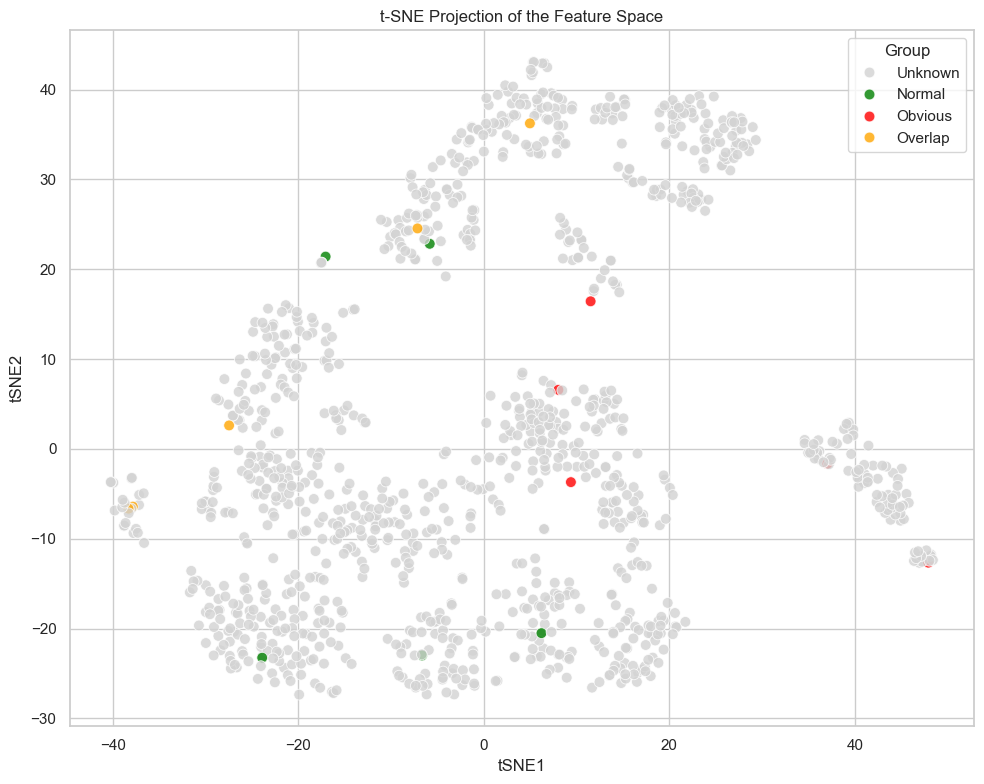

In [49]:
plt.figure(figsize = (10, 8))
sns.scatterplot(data = tsne_df, x = "tSNE1", y = "tSNE2",
                hue = "Group", palette = palette, alpha = 0.8, s = 60)
plt.title("t-SNE Projection of the Feature Space")
plt.tight_layout()
plt.savefig(results_path/"figures"/"feature_space"/"tsne_projection.png",dpi=150)
plt.show()

In [50]:
tsne_df.head()

,tSNE1,tSNE2,Group
0,12.689346,2.851786,Unknown
1,23.429268,27.765757,Unknown
2,14.339861,-2.906878,Unknown
3,-2.194952,23.797190,Unknown
4,4.727193,5.853205,Unknown


## Observations

### 1. PCA captures global variation, not anomaly discrimination.
The first two principal components explain approximately **39% of the total variance**, indicating that the engineered feature space cannot be fully represented in two dimensions. More importantly, the features contributing most to overall variance are not necessarily the features that best distinguish normal and abnormal recordings.
### 2. Spectral Centroid dominates the global feature space.
PCA loadings show that the **Spectral Centroid Family**, particularly its variability measures, contributes most strongly to the principal components. Among the MFCC features, **mfcc_2_mean** is the only coefficient appearing among the strongest loadings, suggesting that it captures broad spectral characteristics closely related to spectral centroid.

### 3. MFCC-1 behaves as a discriminative rather than variance-dominant feature.
Although previous analyses identified **mfcc_1_mean** and **mfcc_1_std** as the strongest features for separating the three recording groups, they contribute relatively little to the principal components. This highlights an important distinction between **explaining overall dataset variance** and **discriminating anomalous recordings**.

### 4. Overlap and Obvious anomalies occupy different regions of the feature space.

Both PCA and t-SNE indicate that the two anomaly groups are not arranged along a single severity continuum. Instead, **Overlap** and **Obvious** anomalies tend to occupy different regions of the feature space, suggesting that they represent distinct acoustic fault mechanisms rather than different degrees of the same failure.

### 5. Normal machine behaviour is multimodal.

The normal recordings are distributed across multiple local clusters rather than forming a single compact group. This indicates that normal machine operation naturally contains several operating states, making anomaly detection substantially more challenging than modelling a single "normal" distribution.

### 6. Implications for model development.

These findings suggest that unsupervised dimensionality reduction alone is insufficient for feature selection, since PCA emphasizes variance rather than anomaly separability. Instead, feature selection should combine evidence from statistical analysis, MFCC experiments, and discriminative feature importance before model training.

Furthermore, the observed multimodal structure of the normal class supports the use of density-estimation methods such as **Normalizing Flows**, which are better suited to modelling complex feature distributions than simpler reconstruction-based approaches.

## Outcome

Feature Space Analysis demonstrates that machine audio anomalies cannot be characterized by a single dominant feature or a single direction of variation. While Spectral Centroid features explain much of the overall dataset variance, MFCC-based features—particularly MFCC-1 and its variability—provide stronger discrimination between normal and anomalous recordings. The analysis also reveals that normal operating behaviour is inherently multimodal and that different anomaly types occupy distinct regions of the feature space. These findings provide a principled basis for feature selection and motivate the use of Normalizing Flows for modelling the complex distribution of normal machine sounds in the subsequent notebooks.